In [2]:
# Import the packages
import pandas as pd
import matplotlib.pyplot as plt
from ord_schema import datasets, huggingface
from ord_schema.message_helpers import get_product_yield
from ord_schema.proto import reaction_pb2

In [3]:
# Define the dataset ID
DATASET_ID = "ord_dataset-5c9a10329a8a48968d18879a48bb8ab2"

# Download the actual ORD parquet file
dataset_path = huggingface.fetch_dataset(DATASET_ID)

# Print its location
print(dataset_path)

data/5c/ord_dataset-5c9a10329a8a48968d18(…): reconstructing file:   0%|          |  0.00B /  713kB            

data/5c/ord_dataset-5c9a10329a8a48968d18(…): downloading bytes:           |  0.00B            

/root/.cache/huggingface/hub/datasets--open-reaction-database--ord-data/snapshots/93475c46949f9218e1dfb6624096025135db2add/data/5c/ord_dataset-5c9a10329a8a48968d18879a48bb8ab2.parquet


In [4]:
# Read the ORD parquet file directly as a pandas DataFrame
ord_df = pd.read_parquet(dataset_path)

# Print the DataFrame shape
print("Shape:", ord_df.shape)

# Print all column names
print("\nColumns:")
for column in ord_df.columns:
    print(column)

Shape: (9632, 2)

Columns:
reaction_id
reaction


In [5]:
# Import the ORD Reaction format and protobuf-to-dictionary converter
from ord_schema.proto import reaction_pb2
from google.protobuf.json_format import MessageToDict

# Take the first serialized reaction from the dataframe
reaction_bytes = ord_df.loc[0, "reaction"]

# Decode it into an ORD Reaction object
rxn = reaction_pb2.Reaction()
rxn.ParseFromString(reaction_bytes)

# Convert the reaction into a normal Python dictionary
rxn_dict = MessageToDict(
    rxn,
    preserving_proto_field_name=True
)

# See the main sections stored inside the reaction
print(rxn_dict.keys())

dict_keys(['inputs', 'setup', 'conditions', 'notes', 'workups', 'outcomes', 'provenance', 'reaction_id'])


In [8]:
# Import the ORD Reaction format and protobuf-to-dictionary converter
from ord_schema.proto import reaction_pb2
from google.protobuf.json_format import MessageToDict

# Take the first serialized reaction from the dataframe
reaction_bytes = ord_df.loc[0, "reaction"]

# Decode it into an ORD Reaction object
rxn = reaction_pb2.Reaction()
rxn.ParseFromString(reaction_bytes)

# Convert the reaction into a normal Python dictionary
rxn_dict = MessageToDict(
    rxn,
    preserving_proto_field_name=True
)

# See the main sections stored inside the reaction
print(rxn_dict.keys())

dict_keys(['inputs', 'setup', 'conditions', 'notes', 'workups', 'outcomes', 'provenance', 'reaction_id'])


In [11]:
#play the complete outcome section of the first reaction
from pprint import pprint

pprint(rxn_dict["outcomes"])

[{'analyses': {'UPLC-MS': {'is_of_isolated_species': False, 'type': 'LCMS'}},
  'products': [{'identifiers': [{'type': 'SMILES',
                                 'value': 'BrC1=CC(S(=O)(NC2=CC=C(C=C2)C(F)(F)F)=O)=CC(C(OC)=O)=C1'}],
                'is_desired_product': True,
                'measurements': [{'analysis_key': 'UPLC-MS',
                                  'authentic_standard': {'identifiers': [{'type': 'SMILES',
                                                                          'value': 'BrC1=CC(S(=O)(NC2=CC=C(C=C2)C(F)(F)F)=O)=CC(C(OC)=O)=C1'}],
                                                         'reaction_role': 'AUTHENTIC_STANDARD'},
                                  'details': 'UPLC-MS Assay Yields',
                                  'is_normalized': True,
                                  'percentage': {'value': 11.269788},
                                  'type': 'YIELD',
                                  'uses_authentic_standard': True,
                

In [15]:
# Create lists to store the mono and diarylation yields
mono_yields = []
di_yields = []

# Loop through every serialized reaction in the ORD dataframe
for reaction_bytes in ord_df["reaction"]:

    # Decode the reaction
    rxn = reaction_pb2.Reaction()
    rxn.ParseFromString(reaction_bytes)

    # Convert it to a normal Python dictionary
    rxn_dict = MessageToDict(
        rxn,
        preserving_proto_field_name=True
    )

    # Look through the products in the reaction outcome
    for product in rxn_dict["outcomes"][0]["products"]:

        # Extract the reported yield
        yield_value = product["measurements"][0]["percentage"]["value"]

        # Store mono-arylation yield
        if product["is_desired_product"] is True:
            mono_yields.append(yield_value)

        # Store diarylation yield
        else:
            di_yields.append(yield_value)

# Check that we extracted one of each per reaction
print("Mono yields:", len(mono_yields))
print("Diarylation yields:", len(di_yields))

# Show the first few values
print("First mono yields:", mono_yields[:5])
print("First diarylation yields:", di_yields[:5])

Mono yields: 9632
Diarylation yields: 9632
First mono yields: [11.269788, 17.964804, 72.11129, 58.950367, 76.839386]
First diarylation yields: [1.2232709, 0.67064446, 5.4166074, 24.80179, 7.9082637]


In [16]:
# Create a unique key for each set of identical reaction conditions
def make_condition_key(reaction_bytes):

    # Decode the stored reaction
    rxn = reaction_pb2.Reaction()
    rxn.ParseFromString(reaction_bytes)

    # Create an empty reaction containing only the information defining the conditions
    temp = reaction_pb2.Reaction()

    # Copy each reaction input individually
    for input_name, reaction_input in rxn.inputs.items():
        temp.inputs[input_name].CopyFrom(reaction_input)

    # Copy the reaction conditions
    temp.conditions.CopyFrom(rxn.conditions)

    # Convert this into a reproducible identifier
    return temp.SerializeToString(deterministic=True)


# Generate a condition key for every experiment
condition_keys = [
    make_condition_key(reaction_bytes)
    for reaction_bytes in ord_df["reaction"]
]


# Combine the condition identity with the two measured yields
yield_df = pd.DataFrame({
    "condition_key": condition_keys,
    "mono_yield": mono_yields,
    "di_yield": di_yields
})


# Check the number of experiments and unique conditions
print("Individual experiments:", len(yield_df))
print("Unique reaction conditions:", yield_df["condition_key"].nunique())

Individual experiments: 9632
Unique reaction conditions: 3552


In [17]:
# Check how many experiments contain a yield greater than 100%
over_100 = yield_df[
    (yield_df["mono_yield"] > 100) |
    (yield_df["di_yield"] > 100)
]

print("Experiments with a yield >100%:", len(over_100))


# Remove any experiment where either reported yield is greater than 100%
yield_df_filtered = yield_df[
    (yield_df["mono_yield"] <= 100) &
    (yield_df["di_yield"] <= 100)
].copy()


# Check the dataset size after filtering
print("Experiments remaining:", len(yield_df_filtered))
print(
    "Unique reaction conditions:",
    yield_df_filtered["condition_key"].nunique()
)

Experiments with a yield >100%: 30
Experiments remaining: 9602
Unique reaction conditions: 3541


In [18]:
# Group identical conditions and calculate replicate statistics
replicate_sd = (
    yield_df_filtered
    .groupby("condition_key")
    .agg(
        n_replicates=("mono_yield", "count"),
        mono_mean=("mono_yield", "mean"),
        mono_SD=("mono_yield", "std"),
        di_mean=("di_yield", "mean"),
        di_SD=("di_yield", "std")
    )
    .reset_index()
)

# Keep only conditions with at least two valid replicate measurements
replicate_sd = replicate_sd[
    replicate_sd["n_replicates"] >= 2
].copy()

# Check how many conditions contribute to the SD analysis
print("Conditions with at least 2 replicates:", len(replicate_sd))

# Show summary statistics for mono-arylation replicate SD
print("\nMono-arylation SD:")
print(replicate_sd["mono_SD"].describe())

# Show summary statistics for diarylation replicate SD
print("\nDiarylation SD:")
print(replicate_sd["di_SD"].describe())

Conditions with at least 2 replicates: 3069

Mono-arylation SD:
count    3069.000000
mean        7.058030
std         7.717383
min         0.000000
25%         1.731371
50%         4.402517
75%         9.552546
max        50.106671
Name: mono_SD, dtype: float64

Diarylation SD:
count    3069.000000
mean        1.650828
std         2.837740
min         0.000000
25%         0.000000
50%         0.541858
75%         2.043669
max        43.979881
Name: di_SD, dtype: float64


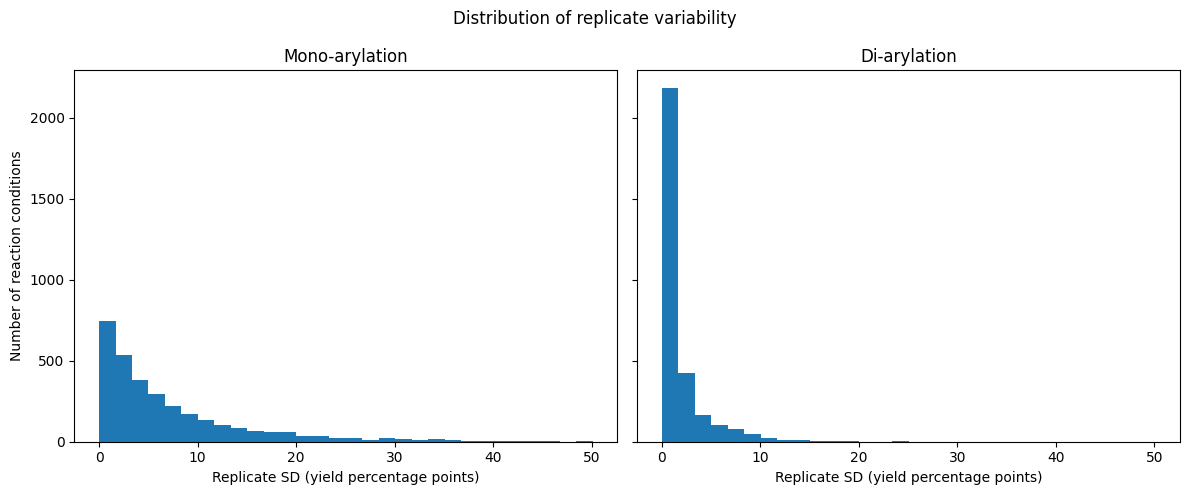

In [19]:
# Import NumPy so both histograms can use identical bins
import numpy as np
import matplotlib.pyplot as plt

# Extract the replicate SD values
mono_sd = replicate_sd["mono_SD"].dropna()
di_sd = replicate_sd["di_SD"].dropna()

# Create identical bins for both histograms
max_sd = max(mono_sd.max(), di_sd.max())
bins = np.linspace(0, max_sd, 31)

# Create two plots side by side
fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5),
    sharex=True,
    sharey=True
)

# Plot mono-arylation replicate SD
axes[0].hist(mono_sd, bins=bins)
axes[0].set_title("Mono-arylation")
axes[0].set_xlabel("Replicate SD (yield percentage points)")
axes[0].set_ylabel("Number of reaction conditions")

# Plot diarylation replicate SD
axes[1].hist(di_sd, bins=bins)
axes[1].set_title("Di-arylation")
axes[1].set_xlabel("Replicate SD (yield percentage points)")

# Add an overall title
fig.suptitle("Distribution of replicate variability")

# Adjust the spacing
plt.tight_layout()

# Display the figure
plt.tight_layout()

plt.savefig("replicate_SD_histograms.png", dpi=300, bbox_inches="tight")


plt.show()

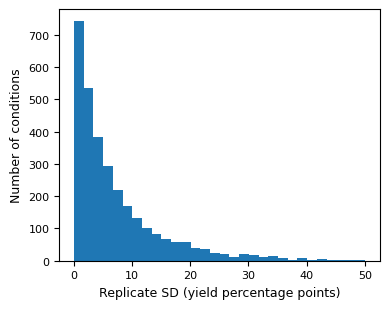

In [20]:
# Extract the mono-arylation replicate SD values
mono_sd = replicate_sd["mono_SD"].dropna()
plt.figure(figsize=(4.0, 3.2))

plt.hist(replicate_sd["mono_SD"], bins=30)

plt.xlabel("Replicate SD (yield percentage points)", fontsize=9)
plt.ylabel("Number of conditions", fontsize=9)

plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

plt.tight_layout()

plt.savefig("monoSD1col.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
# Assign each unique condition to a replicate-SD range
replicate_sd["SD_group"] = pd.cut(
    replicate_sd["mono_SD"],
    bins=[0, 10, 20, 30, 40, float("inf")],
    labels=["0–10", "10–20", "20–30", "30–40", ">40"],
    include_lowest=True
)

# Check how many conditions fall into each SD group
print(replicate_sd["SD_group"].value_counts().sort_index())

SD_group
0–10     2345
10–20     499
20–30     152
30–40      58
>40        15
Name: count, dtype: int64


In [22]:
# Import RDKit
from rdkit import Chem

# Convert a SMILES string into a canonical SMILES
def canonical_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return Chem.MolToSmiles(mol, canonical=True) if mol is not None else smiles

In [23]:
# Create a dictionary to store the chemistry associated with each unique condition
condition_info = {}

for reaction_bytes in ord_df["reaction"]:

    # Generate the same condition key used for the SD analysis
    key = make_condition_key(reaction_bytes)

    # Only process each unique condition once
    if key in condition_info:
        continue

    # Decode the reaction
    rxn = reaction_pb2.Reaction()
    rxn.ParseFromString(reaction_bytes)

    # Store the components belonging to each input category
    info = {}

    for input_name, reaction_input in rxn.inputs.items():

        component_smiles = []

        for component in reaction_input.components:
            for identifier in component.identifiers:

                if identifier.type == 2:
                    component_smiles.append(
                        canonical_smiles(identifier.value)
                    )

        info[input_name] = tuple(component_smiles)

    # Explicitly record whether the condition uses solid, liquid or no base
    if "Base_Solid" in rxn.inputs:
        info["Base_Type"] = "Solid"

    elif "Base_Liquid" in rxn.inputs:
        info["Base_Type"] = "Liquid"

    else:
        info["Base_Type"] = "No base"

    condition_info[key] = info

In [24]:
# Rebuild the chemistry table while keeping the condition key as one column
condition_info_df = pd.DataFrame([
    {
        "condition_key": key,
        **info
    }
    for key, info in condition_info.items()
])

# Check the columns
print(condition_info_df.columns.tolist())

['condition_key', 'Boronic Acid', 'Sulfonamide', 'Base_Solid', 'Catalyst', 'Base_Type', 'Base_Liquid']


In [25]:
# Merge the chemical information with the replicate SD data
sd_chemistry = replicate_sd.merge(
    condition_info_df,
    on="condition_key",
    how="left"
)

# Check the resulting table
display(sd_chemistry.head())

,condition_key,n_replicates,mono_mean,mono_SD,di_mean,di_SD,SD_group,Boronic Acid,Sulfonamide,Base_Solid,Catalyst,Base_Type,Base_Liquid
0,b'\x12K\n\x0bBase_Liquid\x12<\n\x1c\n\r\x08\x0...,3,14.193874,6.721234,0.390784,0.676858,0–10,"(COc1ccc(B(O)O)cc1, CO)","(COCCCCS(N)(=O)=O, CO)",NaN,"(CC#N.CC#N.CC#N.CC#N.F[P-](F)(F)(F)(F)F.[Cu+],)",Liquid,"(CCN(CC)CC,)"
1,b'\x12K\n\x0bBase_Liquid\x12<\n\x1c\n\r\x08\x0...,3,25.332843,11.040379,2.086698,1.194415,10–20,"(COc1ccc(B(O)O)cc1, CO)","(N#CCCCS(N)(=O)=O, CO)",NaN,"(CC#N.CC#N.CC#N.CC#N.F[P-](F)(F)(F)(F)F.[Cu+],)",Liquid,"(CCN(CC)CC,)"
2,b'\x12K\n\x0bBase_Liquid\x12<\n\x1c\n\r\x08\x0...,3,20.764853,10.441018,4.924378,1.678772,10–20,"(COc1ccc(B(O)O)cc1, CO)","(CN(C)CCS(N)(=O)=O, CO)",NaN,"(CC#N.CC#N.CC#N.CC#N.F[P-](F)(F)(F)(F)F.[Cu+],)",Liquid,"(CCN(CC)CC,)"
3,b'\x12K\n\x0bBase_Liquid\x12<\n\x1c\n\r\x08\x0...,3,21.338647,9.081785,1.437610,0.804701,0–10,"(COc1ccc(B(O)O)cc1, CO)","(NS(=O)(=O)c1ccccc1I, CO)",NaN,"(CC#N.CC#N.CC#N.CC#N.F[P-](F)(F)(F)(F)F.[Cu+],)",Liquid,"(CCN(CC)CC,)"
4,b'\x12K\n\x0bBase_Liquid\x12<\n\x1c\n\r\x08\x0...,3,58.104579,2.422936,2.415282,0.466106,0–10,"(COc1ccc(B(O)O)cc1, CO)","(Cc1cc(CS(N)(=O)=O)no1, CO)",NaN,"(CC#N.CC#N.CC#N.CC#N.F[P-](F)(F)(F)(F)F.[Cu+],)",Liquid,"(CCN(CC)CC,)"


In [26]:
# Choose the reaction features we want to compare across SD groups
features = [
    "Base_Type",
    "Catalyst",
    "Sulfonamide",
    "Boronic Acid",
    "Base_Solid",
    "Base_Liquid"
]

# Show the three most common values for each feature within each SD group
for feature in features:

    print(f"\n===== {feature} =====")

    # Remove conditions where this feature is absent
    temp = sd_chemistry.dropna(subset=[feature])

    # Calculate the percentage represented by each value within each SD group
    summary = (
        temp.groupby("SD_group", observed=True)[feature]
            .value_counts(normalize=True)
            .mul(100)
            .rename("Percent")
            .reset_index()
    )

    # Keep the three most common values within each SD group
    top3 = (
        summary.sort_values(["SD_group", "Percent"], ascending=[True, False])
               .groupby("SD_group", observed=True)
               .head(3)
    )

    display(top3)


===== Base_Type =====


,SD_group,Base_Type,Percent
0,0–10,Liquid,55.820896
1,0–10,Solid,23.752665
2,0–10,No base,20.426439
3,10–20,Solid,58.116232
4,10–20,Liquid,36.873747
5,10–20,No base,5.010020
6,20–30,Solid,76.973684
7,20–30,Liquid,18.421053
8,20–30,No base,4.605263
9,30–40,Solid,77.586207



===== Catalyst =====


,SD_group,Catalyst,Percent
0,0–10,(CN(C)CCN(C)C.CN(C)CCN(C)C.[Cl-].[Cl-].[Cu+2]....,26.183369
1,0–10,(O=S(=O)([O-])C(F)(F)F.O=S(=O)([O-])C(F)(F)F.[...,25.287846
2,0–10,"(CC(=O)[O-].CC(=O)[O-].[Cu+2],)",24.605544
4,10–20,"(CC#N.CC#N.CC#N.CC#N.F[P-](F)(F)(F)(F)F.[Cu+],)",29.258517
5,10–20,"(CC(=O)[O-].CC(=O)[O-].[Cu+2],)",26.052104
6,10–20,(O=S(=O)([O-])C(F)(F)F.O=S(=O)([O-])C(F)(F)F.[...,23.647295
8,20–30,"(CC#N.CC#N.CC#N.CC#N.F[P-](F)(F)(F)(F)F.[Cu+],)",28.289474
9,20–30,"(CC(=O)[O-].CC(=O)[O-].[Cu+2],)",27.631579
10,20–30,(O=S(=O)([O-])C(F)(F)F.O=S(=O)([O-])C(F)(F)F.[...,22.368421
12,30–40,(O=S(=O)([O-])C(F)(F)F.O=S(=O)([O-])C(F)(F)F.[...,31.034483



===== Sulfonamide =====


...

,SD_group,Boronic Acid,Percent
0,0–10,"(COc1ccc(B(O)O)cc1, CO)",19.147122
1,0–10,"(COc1ccc(B(O)O)cc1, CC#N)",17.313433
2,0–10,"(COc1ccc(B(O)O)cc1, CCOC(C)=O)",16.204691
8,10–20,"(COc1ccc(B(O)O)cc1, ClCCCl)",23.647295
9,10–20,"(COc1ccc(B(O)O)cc1, CCOC(C)=O)",20.641283
10,10–20,"(COc1ccc(B(O)O)cc1, CC#N)",18.236473
16,20–30,"(COc1ccc(B(O)O)cc1, ClCCCl)",28.947368
17,20–30,"(COc1ccc(B(O)O)cc1, CCOC(C)=O)",21.710526
18,20–30,"(COc1ccc(B(O)O)cc1, CC#N)",17.763158
24,30–40,"(COc1ccc(B(O)O)cc1, ClCCCl)",34.482759



===== Base_Solid =====


,SD_group,Base_Solid,Percent
0,0–10,"(O=P([O-])([O-])[O-].[K+].[K+].[K+],)",52.423698
1,0–10,"(O=C([O-])[O-].[K+].[K+],)",47.576302
2,10–20,"(O=C([O-])[O-].[K+].[K+],)",50.344828
3,10–20,"(O=P([O-])([O-])[O-].[K+].[K+].[K+],)",49.655172
4,20–30,"(O=C([O-])[O-].[K+].[K+],)",55.555556
5,20–30,"(O=P([O-])([O-])[O-].[K+].[K+].[K+],)",44.444444
6,30–40,"(O=C([O-])[O-].[K+].[K+],)",62.222222
7,30–40,"(O=P([O-])([O-])[O-].[K+].[K+].[K+],)",37.777778
8,>40,"(O=C([O-])[O-].[K+].[K+],)",58.333333
9,>40,"(O=P([O-])([O-])[O-].[K+].[K+].[K+],)",41.666667



===== Base_Liquid =====


,SD_group,Base_Liquid,Percent
0,0–10,"(CCN(CC)CC,)",34.224599
1,0–10,"(CN(C)c1ccncc1,)",33.078686
2,0–10,"(CCN(C(C)C)C(C)C,)",32.696715
3,10–20,"(CCN(C(C)C)C(C)C,)",36.413043
4,10–20,"(CN(C)c1ccncc1,)",33.152174
5,10–20,"(CCN(CC)CC,)",30.434783
6,20–30,"(CN(C)c1ccncc1,)",42.857143
7,20–30,"(CCN(C(C)C)C(C)C,)",39.285714
8,20–30,"(CCN(CC)CC,)",17.857143
9,30–40,"(CCN(C(C)C)C(C)C,)",46.153846


In [47]:
# Map the solvent SMILES used in the dataset to readable names
solvent_map = {
    "ClCCCl": "DCE",
    "CC#N": "MeCN",
    "CO": "MeOH",
    "CCOC(C)=O": "EtOAc"
}

# Extract solvent identity from a reaction-component tuple
def get_solvent(components):
    if not isinstance(components, tuple):
        return None

    for smi in components:
        if smi in solvent_map:
            return solvent_map[smi]

    return None


# Extract the solvent stored with both reaction components
boronic_solvent = sd_chemistry["Boronic Acid"].apply(get_solvent)
sulfonamide_solvent = sd_chemistry["Sulfonamide"].apply(get_solvent)

# Confirm that the two solvent fields are identical
solvent_match = (
    boronic_solvent.fillna("Missing")
    == sulfonamide_solvent.fillna("Missing")
)

print("Matching solvent assignments:", solvent_match.sum())
print("Mismatched solvent assignments:", (~solvent_match).sum())

if (~solvent_match).any():
    print("Warning: mismatched solvent assignments found.")
else:
    print("Boronic-acid and sulfonamide solvent assignments are identical for all conditions.")


# Since both solvent fields are identical, use one variable for analysis
sd_chemistry["Solvent"] = boronic_solvent

# Check solvent counts
print("\nSolvent counts:")
print(sd_chemistry["Solvent"].value_counts(dropna=False))

Matching solvent assignments: 3069
Mismatched solvent assignments: 0
Boronic-acid and sulfonamide solvent assignments are identical for all conditions.

Solvent counts:
Solvent
MeOH     768
MeCN     768
EtOAc    768
DCE      765
Name: count, dtype: int64


In [28]:
# Calculate the percentage of each solvent within each SD group
solvent_by_sd = pd.crosstab(
    sd_chemistry["SD_group"],
    sd_chemistry["Solvent"],
    normalize="index"
) * 100

# Put the SD groups in order
solvent_by_sd = solvent_by_sd.reindex(
    ["0–10", "10–20", "20–30", "30–40", ">40"]
)

# Display the percentages
display(solvent_by_sd.round(1))

Solvent,DCE,EtOAc,MeCN,MeOH
SD_group,,,,
0–10,22.5,24.3,25.7,27.5
10–20,29.3,28.5,24.0,18.2
20–30,36.8,27.6,24.3,11.2
30–40,50.0,25.9,8.6,15.5
>40,40.0,0.0,26.7,33.3


In [29]:
# See how strongly solvent and base type are associated
solvent_base = pd.crosstab(
    sd_chemistry["Solvent"],
    sd_chemistry["Base_Type"],
    normalize="index"
) * 100

display(solvent_base.round(1))

Base_Type,Liquid,No base,Solid
Solvent,,,
DCE,50.2,16.7,33.1
EtOAc,50.0,16.7,33.3
MeCN,50.0,16.7,33.3
MeOH,50.0,16.7,33.3


In [32]:
# Extract the actual sulfonamide, excluding the solvent stored in the same tuple
def get_non_solvent_component(components):
    if not isinstance(components, tuple):
        return None

    for smi in components:
        if smi not in solvent_map:
            return smi

    return None


# Create clean columns containing only the chemical identity
sd_chemistry["Sulfonamide_Only"] = sd_chemistry["Sulfonamide"].apply(
    get_non_solvent_component
)

sd_chemistry["Boronic_Acid_Only"] = sd_chemistry["Boronic Acid"].apply(
    get_non_solvent_component
)

# Convert catalyst tuples into simple strings
sd_chemistry["Catalyst_Only"] = sd_chemistry["Catalyst"].apply(
    lambda x: x[0] if isinstance(x, tuple) and len(x) > 0 else x
)

In [33]:
# Compare catalyst distribution across solvents
display(
    (pd.crosstab(
        sd_chemistry["Solvent"],
        sd_chemistry["Catalyst_Only"],
        normalize="index"
    ) * 100).round(1)
)

Catalyst_Only,CC#N.CC#N.CC#N.CC#N.F[P-](F)(F)(F)(F)F.[Cu+],CC(=O)[O-].CC(=O)[O-].[Cu+2],CN(C)CCN(C)C.CN(C)CCN(C)C.[Cl-].[Cl-].[Cu+2].[Cu+2].[OH-].[OH-],O=S(=O)([O-])C(F)(F)F.O=S(=O)([O-])C(F)(F)F.[Cu+2]
Solvent,,,,
DCE,25.1,25.0,25.0,25.0
EtOAc,25.0,25.0,25.0,25.0
MeCN,25.0,25.0,25.0,25.0
MeOH,25.0,25.0,25.0,25.0


In [34]:
# Compare sulfonamide distribution across solvents
display(
    (pd.crosstab(
        sd_chemistry["Solvent"],
        sd_chemistry["Sulfonamide_Only"],
        normalize="index"
    ) * 100).round(1)
)

Sulfonamide_Only,CC(C)(C)OC(=O)N1CCC(S(N)(=O)=O)CC1,CCOC(=O)c1ccccc1S(N)(=O)=O,CCOc1ccc(S(N)(=O)=O)cc1OCC,CN(C)C(=O)c1cccnc1S(N)(=O)=O,CN(C)CCS(N)(=O)=O,COC(=O)c1cc(Br)cc(S(N)(=O)=O)c1,COC(=O)c1oc(S(N)(=O)=O)cc1C,COCCCCS(N)(=O)=O,COCCOc1ccccc1S(N)(=O)=O,COc1cccc2c(S(N)(=O)=O)cccc12,...,Cn1cc(S(N)(=O)=O)c2ccccc21,N#CCCCS(N)(=O)=O,NS(=O)(=O)CCc1ccccc1,NS(=O)(=O)Cc1cccc(C(F)(F)F)c1,NS(=O)(=O)c1cc(Cl)c(F)cc1Cl,NS(=O)(=O)c1ccc(-c2ccccn2)s1,NS(=O)(=O)c1ccc([N+](=O)[O-])cc1,NS(=O)(=O)c1ccc2c(c1)CCC2,NS(=O)(=O)c1cccc(F)n1,NS(=O)(=O)c1ccccc1I
Solvent,,,,,,,,,,,,,,,,,,,,,
DCE,3.1,6.3,3.1,3.1,6.3,6.3,6.3,3.1,6.3,3.1,...,3.1,6.3,3.1,3.1,3.1,3.1,3.1,3.1,6.3,5.9
EtOAc,3.1,6.2,3.1,3.1,6.2,6.2,6.2,3.1,6.2,3.1,...,3.1,6.2,3.1,3.1,3.1,3.1,3.1,3.1,6.2,6.2
MeCN,3.1,6.2,3.1,3.1,6.2,6.2,6.2,3.1,6.2,3.1,...,3.1,6.2,3.1,3.1,3.1,3.1,3.1,3.1,6.2,6.2
MeOH,3.1,6.2,3.1,3.1,6.2,6.2,6.2,3.1,6.2,3.1,...,3.1,6.2,3.1,3.1,3.1,3.1,3.1,3.1,6.2,6.2


In [35]:
# Compare boronic acid distribution across solvents
display(
    (pd.crosstab(
        sd_chemistry["Solvent"],
        sd_chemistry["Boronic_Acid_Only"],
        normalize="index"
    ) * 100).round(1)
)

Boronic_Acid_Only,COc1ccc(B(O)O)cc1,OB(O)c1ccc(C(F)(F)F)cc1
Solvent,,
DCE,68.6,31.4
EtOAc,68.8,31.2
MeCN,68.8,31.2
MeOH,68.8,31.2


In [ ]:
# Calculate the mean and median mono-arylation replicate SD for each solvent
solvent_sd_summary = (
    sd_chemistry.groupby("Solvent", observed=True)["mono_SD"]
    .agg(
        count="count",
        mean_SD="mean",
        median_SD="median"
    )
    .sort_values("median_SD", ascending=False)
)

# Display the summary
display(solvent_sd_summary.round(2))

,count,mean_SD,median_SD
Solvent,,,
DCE,765,8.89,5.89
EtOAc,768,7.21,4.45
MeCN,768,6.58,4.21
MeOH,768,5.55,3.28


In [36]:
# Import the statistical test
from scipy.stats import kruskal

# Collect the replicate SD values for each solvent
groups = [
    sd_chemistry.loc[sd_chemistry["Solvent"] == solvent, "mono_SD"].dropna()
    for solvent in ["DCE", "EtOAc", "MeCN", "MeOH"]
]

# Test whether replicate variability differs between solvents
stat, p = kruskal(*groups)

print("Kruskal-Wallis statistic:", round(stat, 3))
print("p-value:", p)

Kruskal-Wallis statistic: 76.988
p-value: 1.3584386162625288e-16


In [37]:
# Count the number of unique reaction conditions for each base type
print(sd_chemistry["Base_Type"].value_counts())

Base_Type
Liquid     1536
Solid      1021
No base     512
Name: count, dtype: int64


In [38]:
# Summarise mono-arylation replicate SD for each base type
base_sd_summary = (
    sd_chemistry.groupby("Base_Type")["mono_SD"]
    .agg(
        count="count",
        mean_SD="mean",
        median_SD="median"
    )
    .sort_values("median_SD", ascending=False)
)

display(base_sd_summary.round(2))

,count,mean_SD,median_SD
Base_Type,,,
Solid,1021,11.34,8.82
Liquid,1536,5.61,3.85
No base,512,2.87,1.10


In [39]:
# Import the Kruskal-Wallis test
from scipy.stats import kruskal

# Collect the SD values for each base type
groups = [
    sd_chemistry.loc[
        sd_chemistry["Base_Type"] == base_type,
        "mono_SD"
    ].dropna()
    for base_type in ["Solid", "Liquid", "No base"]
]

# Test whether replicate variability differs between base types
stat, p = kruskal(*groups)

print("Kruskal-Wallis statistic:", round(stat, 3))
print("p-value:", p)

Kruskal-Wallis statistic: 652.945
p-value: 1.6395027390782262e-142


In [40]:
# Import the pairwise test
from scipy.stats import mannwhitneyu

base_types = ["Solid", "Liquid", "No base"]

# Compare every pair of base types
for i in range(len(base_types)):
    for j in range(i + 1, len(base_types)):

        group1 = sd_chemistry.loc[
            sd_chemistry["Base_Type"] == base_types[i],
            "mono_SD"
        ].dropna()

        group2 = sd_chemistry.loc[
            sd_chemistry["Base_Type"] == base_types[j],
            "mono_SD"
        ].dropna()

        stat, p = mannwhitneyu(
            group1,
            group2,
            alternative="two-sided"
        )

        # Bonferroni correction for 3 pairwise comparisons
        corrected_p = min(p * 3, 1)

        print(
            f"{base_types[i]} vs {base_types[j]}: "
            f"corrected p = {corrected_p:.3e}"
        )

Solid vs Liquid: corrected p = 2.208e-65
Solid vs No base: corrected p = 2.106e-106
Liquid vs No base: corrected p = 4.804e-59


In [41]:
# Import the pairwise test
from scipy.stats import mannwhitneyu

# Define the solvent groups
solvents = ["DCE", "EtOAc", "MeCN", "MeOH"]

# Compare every pair of solvents
for i in range(len(solvents)):
    for j in range(i + 1, len(solvents)):

        group1 = sd_chemistry.loc[
            sd_chemistry["Solvent"] == solvents[i],
            "mono_SD"
        ].dropna()

        group2 = sd_chemistry.loc[
            sd_chemistry["Solvent"] == solvents[j],
            "mono_SD"
        ].dropna()

        stat, p = mannwhitneyu(
            group1,
            group2,
            alternative="two-sided"
        )

        # Bonferroni correction for 6 pairwise comparisons
        corrected_p = min(p * 6, 1)

        print(
            f"{solvents[i]} vs {solvents[j]}: "
            f"corrected p = {corrected_p:.3e}"
        )

DCE vs EtOAc: corrected p = 4.038e-04
DCE vs MeCN: corrected p = 1.157e-06
DCE vs MeOH: corrected p = 2.252e-17
EtOAc vs MeCN: corrected p = 1.000e+00
EtOAc vs MeOH: corrected p = 2.479e-05
MeCN vs MeOH: corrected p = 1.724e-03


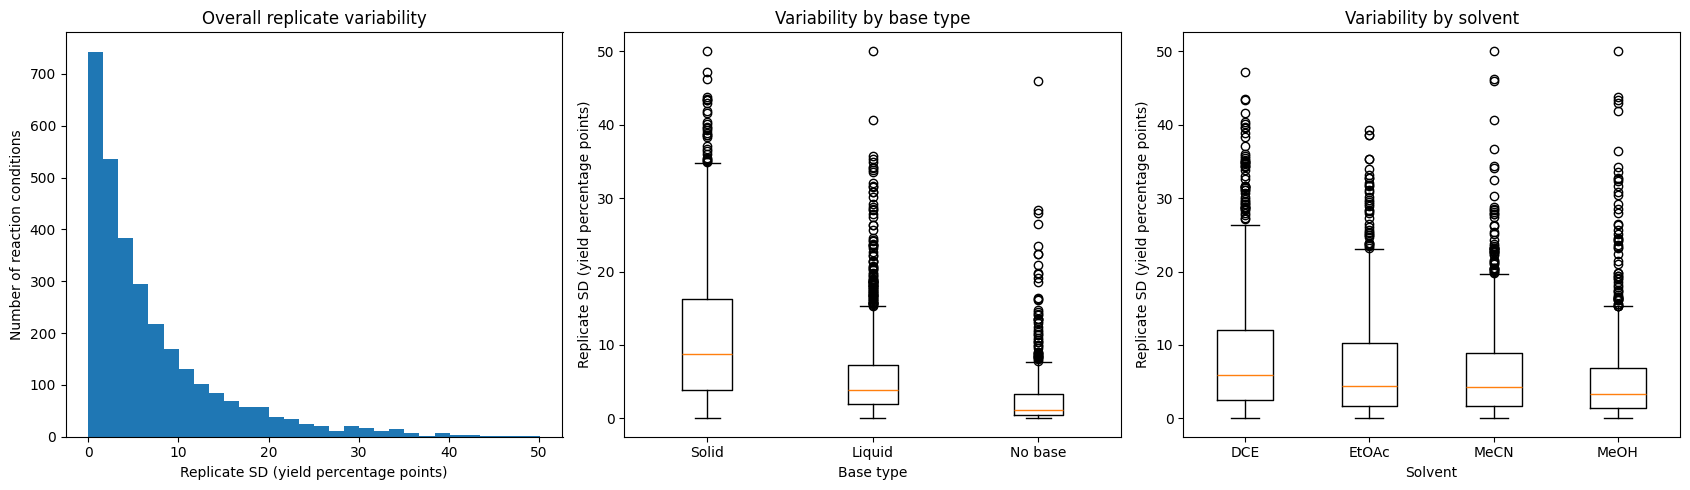

In [42]:
# Define the order of groups
base_order = ["Solid", "Liquid", "No base"]
solvent_order = ["DCE", "EtOAc", "MeCN", "MeOH"]

# Create one figure with three panels
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# 1. Overall distribution of mono-arylation replicate SD
axes[0].hist(replicate_sd["mono_SD"].dropna(), bins=30)
axes[0].set_xlabel("Replicate SD (yield percentage points)")
axes[0].set_ylabel("Number of reaction conditions")
axes[0].set_title("Overall replicate variability")

# 2. Replicate SD grouped by base type
base_data = [
    sd_chemistry.loc[
        sd_chemistry["Base_Type"] == group,
        "mono_SD"
    ].dropna()
    for group in base_order
]

axes[1].boxplot(base_data, tick_labels=base_order)
axes[1].set_xlabel("Base type")
axes[1].set_ylabel("Replicate SD (yield percentage points)")
axes[1].set_title("Variability by base type")

# 3. Replicate SD grouped by solvent
solvent_data = [
    sd_chemistry.loc[
        sd_chemistry["Solvent"] == group,
        "mono_SD"
    ].dropna()
    for group in solvent_order
]

axes[2].boxplot(solvent_data, tick_labels=solvent_order)
axes[2].set_xlabel("Solvent")
axes[2].set_ylabel("Replicate SD (yield percentage points)")
axes[2].set_title("Variability by solvent")

# Adjust spacing
plt.tight_layout()

# Show the figure
plt.show()

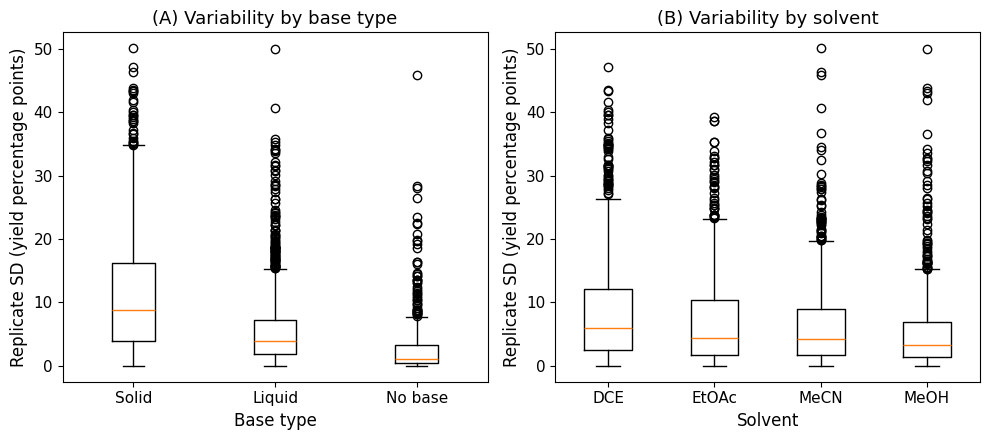

In [43]:
import matplotlib.pyplot as plt

# Define the order of groups
base_order = ["Solid", "Liquid", "No base"]
solvent_order = ["DCE", "EtOAc", "MeCN", "MeOH"]

# Prepare grouped data
base_data = [
    sd_chemistry.loc[
        sd_chemistry["Base_Type"] == group,
        "mono_SD"
    ].dropna()
    for group in base_order
]

solvent_data = [
    sd_chemistry.loc[
        sd_chemistry["Solvent"] == group,
        "mono_SD"
    ].dropna()
    for group in solvent_order
]

# Create figure with two side-by-side boxplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# 1. Boxplot by base type
axes[0].boxplot(base_data, tick_labels=base_order)
axes[0].set_xlabel("Base type", fontsize=12)
axes[0].set_ylabel("Replicate SD (yield percentage points)", fontsize=12)
axes[0].set_title("(A) Variability by base type", fontsize=13)
axes[0].tick_params(axis='both', labelsize=11)

# 2. Boxplot by solvent
axes[1].boxplot(solvent_data, tick_labels=solvent_order)
axes[1].set_xlabel("Solvent", fontsize=12)
axes[1].set_ylabel("Replicate SD (yield percentage points)", fontsize=12)
axes[1].set_title("(B) Variability by solvent", fontsize=13)
axes[1].tick_params(axis='both', labelsize=11)


# Tidy layout
plt.tight_layout()

# Save high-resolution version for manuscript use
plt.savefig("mono_sd_boxplots.png", dpi=300, bbox_inches="tight")

# Show figure
plt.show()

In [44]:
# Summarise replicate SD by base type
base_summary = (
    sd_chemistry.groupby("Base_Type")["mono_SD"]
    .agg(
        n="count",
        mean_SD="mean",
        median_SD="median"
    )
    .reindex(base_order)
    .round(2)
)

# Summarise replicate SD by solvent
solvent_summary = (
    sd_chemistry.groupby("Solvent")["mono_SD"]
    .agg(
        n="count",
        mean_SD="mean",
        median_SD="median"
    )
    .reindex(solvent_order)
    .round(2)
)

print("BASE TYPE")
display(base_summary)

print("\nSOLVENT")
display(solvent_summary)

BASE TYPE


,n,mean_SD,median_SD
Base_Type,,,
Solid,1021,11.34,8.82
Liquid,1536,5.61,3.85
No base,512,2.87,1.10



SOLVENT


,n,mean_SD,median_SD
Solvent,,,
DCE,765,8.89,5.89
EtOAc,768,7.21,4.45
MeCN,768,6.58,4.21
MeOH,768,5.55,3.28


In [45]:
from scipy.stats import kruskal

# Test whether SD differs between base types
base_groups = [
    sd_chemistry.loc[
        sd_chemistry["Base_Type"] == group,
        "mono_SD"
    ].dropna()
    for group in base_order
]

base_stat, base_p = kruskal(*base_groups)

# Test whether SD differs between solvents
solvent_groups = [
    sd_chemistry.loc[
        sd_chemistry["Solvent"] == group,
        "mono_SD"
    ].dropna()
    for group in solvent_order
]

solvent_stat, solvent_p = kruskal(*solvent_groups)

# Display the results
print(f"Base type: Kruskal–Wallis p = {base_p:.3e}")
print(f"Solvent:   Kruskal–Wallis p = {solvent_p:.3e}")

Base type: Kruskal–Wallis p = 1.640e-142
Solvent:   Kruskal–Wallis p = 1.358e-16


In [46]:
# Check whether base type is associated with the other major reaction variables

base_order = ["Solid", "Liquid", "No base"]

features_to_check = [
    "Solvent",
    "Catalyst_Only",
    "Boronic_Acid_Only",
    "Sulfonamide_Only"
]

for feature in features_to_check:

    print(f"\n===== {feature} distribution across base types =====")

    # Percentage distribution of each feature within each base-type group
    table = (
        pd.crosstab(
            sd_chemistry["Base_Type"],
            sd_chemistry[feature],
            normalize="index"
        ) * 100
    )

    # Keep base types in a consistent order
    table = table.reindex(base_order)

    display(table.round(1))

    # Quantify the largest difference in representation
    # of each category across the three base types
    percentage_range = (
        table.max(axis=0) - table.min(axis=0)
    ).sort_values(ascending=False)

    print("Largest percentage-point differences across base types:")
    display(percentage_range.head(10).round(1))


===== Solvent distribution across base types =====


Solvent,DCE,EtOAc,MeCN,MeOH
Base_Type,,,,
Solid,24.8,25.1,25.1,25.1
Liquid,25.0,25.0,25.0,25.0
No base,25.0,25.0,25.0,25.0


Largest percentage-point differences across base types:


,0
Solvent,
DCE,0.2
EtOAc,0.1
MeCN,0.1
MeOH,0.1



===== Catalyst_Only distribution across base types =====


...

,0
Boronic_Acid_Only,
OB(O)c1ccc(C(F)(F)F)cc1,0.1
COc1ccc(B(O)O)cc1,0.1



===== Sulfonamide_Only distribution across base types =====


Sulfonamide_Only,CC(C)(C)OC(=O)N1CCC(S(N)(=O)=O)CC1,CCOC(=O)c1ccccc1S(N)(=O)=O,CCOc1ccc(S(N)(=O)=O)cc1OCC,CN(C)C(=O)c1cccnc1S(N)(=O)=O,CN(C)CCS(N)(=O)=O,COC(=O)c1cc(Br)cc(S(N)(=O)=O)c1,COC(=O)c1oc(S(N)(=O)=O)cc1C,COCCCCS(N)(=O)=O,COCCOc1ccccc1S(N)(=O)=O,COc1cccc2c(S(N)(=O)=O)cccc12,...,Cn1cc(S(N)(=O)=O)c2ccccc21,N#CCCCS(N)(=O)=O,NS(=O)(=O)CCc1ccccc1,NS(=O)(=O)Cc1cccc(C(F)(F)F)c1,NS(=O)(=O)c1cc(Cl)c(F)cc1Cl,NS(=O)(=O)c1ccc(-c2ccccn2)s1,NS(=O)(=O)c1ccc([N+](=O)[O-])cc1,NS(=O)(=O)c1ccc2c(c1)CCC2,NS(=O)(=O)c1cccc(F)n1,NS(=O)(=O)c1ccccc1I
Base_Type,,,,,,,,,,,,,,,,,,,,,
Solid,3.1,6.3,3.1,3.1,6.3,6.3,6.3,3.1,6.3,3.1,...,3.1,6.3,3.1,3.1,3.1,3.1,3.1,3.1,6.3,6.0
Liquid,3.1,6.2,3.1,3.1,6.2,6.2,6.2,3.1,6.2,3.1,...,3.1,6.2,3.1,3.1,3.1,3.1,3.1,3.1,6.2,6.2
No base,3.1,6.2,3.1,3.1,6.2,6.2,6.2,3.1,6.2,3.1,...,3.1,6.2,3.1,3.1,3.1,3.1,3.1,3.1,6.2,6.2


Largest percentage-point differences across base types:


,0
Sulfonamide_Only,
NS(=O)(=O)c1ccccc1I,0.3
CCOC(=O)c1ccccc1S(N)(=O)=O,0.0
CN(C)CCS(N)(=O)=O,0.0
Cc1ccc(-c2cc(C(F)(F)F)nn2-c2ccc(S(N)(=O)=O)cc2)cc1,0.0
COC(=O)c1oc(S(N)(=O)=O)cc1C,0.0
COC(=O)c1cc(Br)cc(S(N)(=O)=O)c1,0.0
N#CCCCS(N)(=O)=O,0.0
Cc1cc(CS(N)(=O)=O)no1,0.0
NS(=O)(=O)c1cccc(F)n1,0.0
